To run the example install the extra dependencies mentioned in the Readme or pyproject.toml or run this code
```
uv sync --extra example
```

In [22]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import time

%matplotlib inline

In [2]:
from mlp import MLP

## Dataset Selection

In [3]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
dataset = fetch_ucirepo(id=602)

In [4]:
# data (as pandas dataframes)
X: pd.DataFrame = dataset.data.features
y: pd.DataFrame = dataset.data.targets

# metadata
print(dataset.metadata)

# variable information
print(dataset.variables)

{'uci_id': 602, 'name': 'Dry Bean', 'repository_url': 'https://archive.ics.uci.edu/dataset/602/dry+bean+dataset', 'data_url': 'https://archive.ics.uci.edu/static/public/602/data.csv', 'abstract': 'Images of 13,611 grains of 7 different registered dry beans were taken with a high-resolution camera. A total of 16 features; 12 dimensions and 4 shape forms, were obtained from the grains.', 'area': 'Biology', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 13611, 'num_features': 16, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['Class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2020, 'last_updated': 'Thu Mar 28 2024', 'dataset_doi': '10.24432/C50S4B', 'creators': [], 'intro_paper': {'ID': 244, 'type': 'NATIVE', 'title': 'Multiclass classification of dry beans using computer vision and machine learning techniques', 'authors': 'M. Koklu, Ilker Ali Özkan', 'venue': 'Co

In [5]:
n_features = X.shape[1]
n_classes = len(np.unique(y))

print("Dataset Information:")
print(f"Number of samples: {X.shape[0]}")
print(f"Number of features: {n_features}")
print(f"Number of classes: {n_classes}")
print(f"Feature names: {X.columns.tolist()}")
print(f"Class names: {np.unique(y)}")
print(f"Class distribution: {y.value_counts()}")

Dataset Information:
Number of samples: 13611
Number of features: 16
Number of classes: 7
Feature names: ['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'AspectRatio', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent', 'Solidity', 'Roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor3', 'ShapeFactor4']
Class names: ['BARBUNYA' 'BOMBAY' 'CALI' 'DERMASON' 'HOROZ' 'SEKER' 'SIRA']
Class distribution: Class   
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64


Primary metric: Macro F1 — chosen because of mild class imbalance (BOMBAY has 522 samples vs DERMASON's 3546). Macro F1 weights all classes equally regardless of size.

## Dataset Preprocessing

In [6]:
# Doing Label Encoding in the target class
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y["Class"])
y_encoded


array([5, 5, 5, ..., 3, 3, 3], shape=(13611,))

In [7]:
# Splitting data into train and temp set
X_train, X_temp, y_train_labels, y_temp_labels = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Splitting data into test and validation set
X_val, X_test, y_val_labels, y_test_labels = train_test_split(
    X_temp, y_temp_labels, test_size=0.50, random_state=42, stratify=y_temp_labels
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Validation set size: {X_val.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print()

Training set size: 10888
Validation set size: 1361
Test set size: 1362



In [8]:
def one_hot_encode(y, n_classes):
    """
    Convert class labels to one-hot encoding
    """
    N = len(y)
    y_one_hot = np.zeros((N, n_classes))
    y_one_hot[np.arange(N), y] = 1
    return y_one_hot

# Doing one hot encoding in the target class
y_train = one_hot_encode(y_train_labels, n_classes)
y_val = one_hot_encode(y_val_labels, n_classes)
y_test = one_hot_encode(y_test_labels, n_classes)

In [9]:
# Doing standard scaler in X_train, X_val X_test
standard_scaler = StandardScaler()

X_train_scaled = standard_scaler.fit_transform(X_train)
X_val_scaled = standard_scaler.transform(X_val)
X_test_scaled = standard_scaler.transform(X_test)

## MLP Training

In [17]:
architecture = [n_features, 32, 16, n_classes]

model = MLP(architecture=architecture, learning_rate=0.01, batch_size=256, random_state=42)

model.summary()

MLP Archiecture [16, 32, 16, 7]
--------------------------------------------------
Layer 1: 16 -> 32 (ReLU) | Params: 544
Layer 2: 32 -> 16 (ReLU) | Params: 528
Layer 3: 16 -> 7 (Softmax) | Params: 119
--------------------------------------------------
Total params: 1,191


In [18]:
model.fit(X = X_train_scaled, y = y_train, X_val= X_val_scaled, y_val=y_val, epochs=1000, patience=15)

Epoch   0 | Train Loss: 1.9343, Acc: 0.4079 | Val Loss: 1.4935, Acc: 0.3968
Epoch  10 | Train Loss: 0.5152, Acc: 0.8743 | Val Loss: 0.4885, Acc: 0.8729
Epoch  20 | Train Loss: 0.3393, Acc: 0.9065 | Val Loss: 0.3214, Acc: 0.9126
Epoch  30 | Train Loss: 0.2801, Acc: 0.9143 | Val Loss: 0.2649, Acc: 0.9192
Epoch  40 | Train Loss: 0.2535, Acc: 0.9180 | Val Loss: 0.2401, Acc: 0.9192
Epoch  50 | Train Loss: 0.2385, Acc: 0.9213 | Val Loss: 0.2273, Acc: 0.9214
Epoch  60 | Train Loss: 0.2304, Acc: 0.9235 | Val Loss: 0.2201, Acc: 0.9236
Epoch  70 | Train Loss: 0.2237, Acc: 0.9246 | Val Loss: 0.2145, Acc: 0.9243
Epoch  80 | Train Loss: 0.2186, Acc: 0.9247 | Val Loss: 0.2106, Acc: 0.9265
Epoch  90 | Train Loss: 0.2141, Acc: 0.9259 | Val Loss: 0.2079, Acc: 0.9258
Epoch 100 | Train Loss: 0.2104, Acc: 0.9264 | Val Loss: 0.2052, Acc: 0.9258
Epoch 110 | Train Loss: 0.2082, Acc: 0.9269 | Val Loss: 0.2031, Acc: 0.9273
Epoch 120 | Train Loss: 0.2060, Acc: 0.9278 | Val Loss: 0.2012, Acc: 0.9265
Epoch 130 | 

In [19]:
predictions = model.predict(X_test_scaled)
predictions

array([0, 3, 3, ..., 6, 0, 3], shape=(1362,))

In [20]:
np.mean(predictions == y_test_labels)

np.float64(0.9236417033773862)

In [25]:
def plot_training_history(model):
    """Plot training loss and accuracy"""
    # DFNN format
    train_losses = model.history["train_loss"]
    val_losses = model.history["val_loss"]
    train_accs = model.history["train_acc"]
    val_accs = model.history["val_acc"]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    epochs = range(len(train_losses))

    # Plot loss
    ax1.plot(epochs, train_losses, "b-", linewidth=2, label="Training Loss")
    if val_losses:
        ax1.plot(epochs, val_losses, "r-", linewidth=2, label="Validation Loss")
    ax1.set_xlabel("Epoch", fontsize=12)
    ax1.set_ylabel("Loss (Categorical Cross-Entropy)", fontsize=12)
    ax1.set_title("Loss over Epochs", fontsize=14, fontweight="bold")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot accuracy
    ax2.plot(epochs, train_accs, "b-", linewidth=2, label="Training Accuracy")
    if val_accs:
        ax2.plot(epochs, val_accs, "r-", linewidth=2, label="Validation Accuracy")
    ax2.set_xlabel("Epoch", fontsize=12)
    ax2.set_ylabel("Accuracy", fontsize=12)
    ax2.set_title("Accuracy over Epochs", fontsize=14, fontweight="bold")
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim([0, 1])

    plt.tight_layout()
    plt.show()

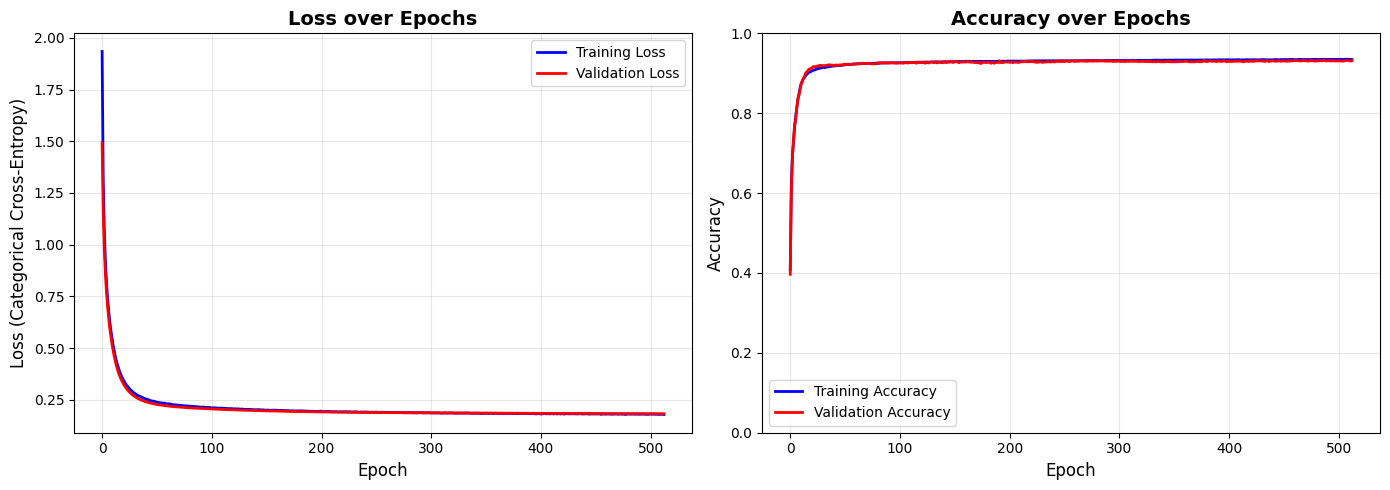

In [26]:
plot_training_history(model)